In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler # creating duplicate values of the less column values
from sklearn.preprocessing import StandardScaler #scale the values by average value and mean value
import tensorflow as tf #for neural network
from sklearn.metrics import classification_report #classification report

In [7]:
data_frame = pd.read_csv("/content/diabetes.csv")
data_frame.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
data_frame['Outcome'].unique()

array([1, 0])

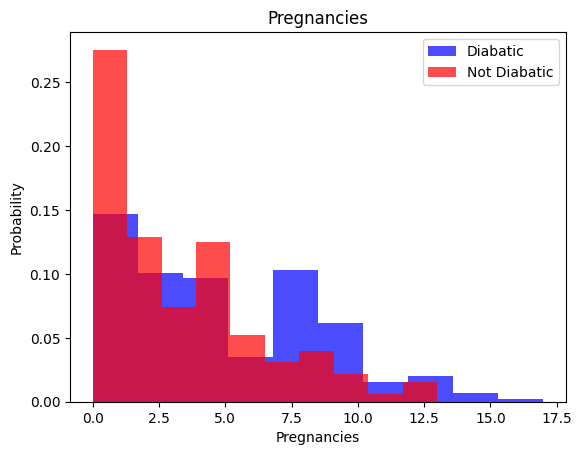

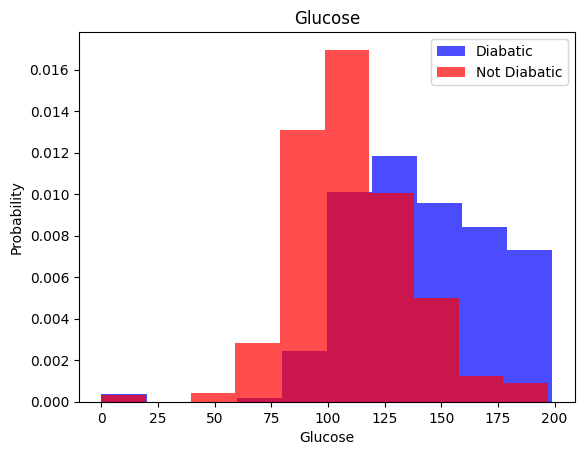

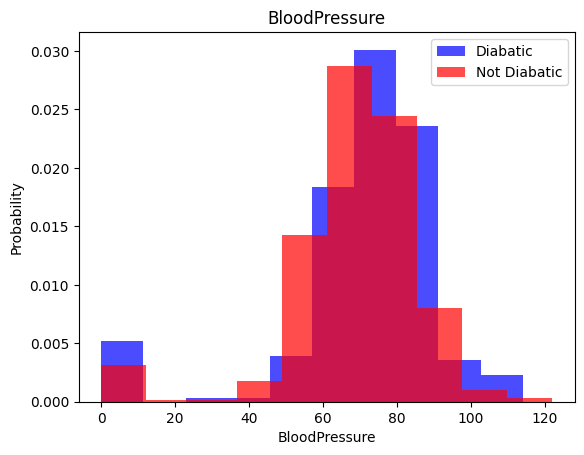

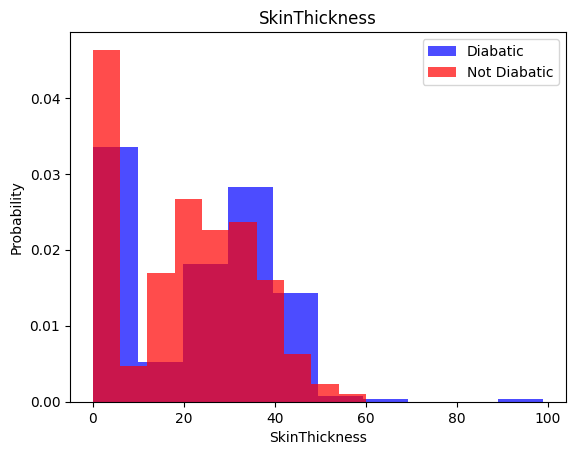

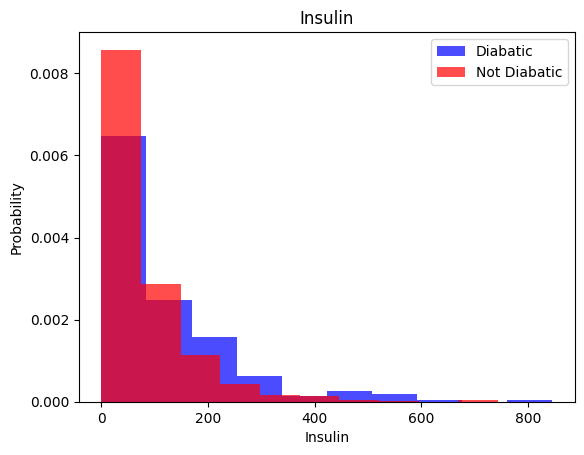

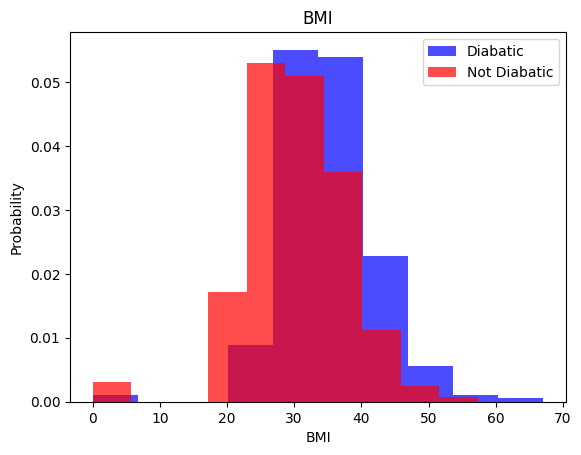

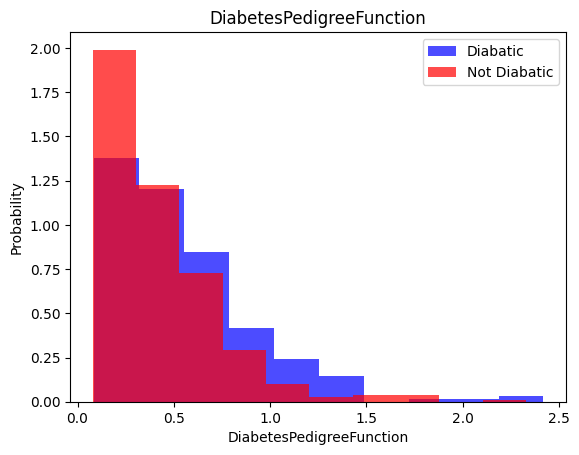

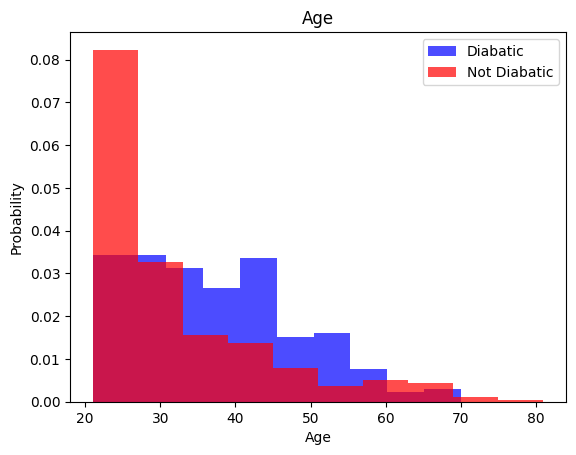

In [9]:
columns_names = ["Pregnancies",	"Glucose",	"BloodPressure",	"SkinThickness",	"Insulin",	"BMI",	"DiabetesPedigreeFunction",	"Age",	"Outcome"]
for label in columns_names[:-1]:
  plt.hist(data_frame[data_frame["Outcome"] == 1][label], color="blue", alpha=0.7, label = "Diabatic", density = True)
  plt.hist(data_frame[data_frame["Outcome"] == 0][label], color="red", alpha=0.7, label = "Not Diabatic", density = True)

  plt.title(label)
  plt.ylabel("Probability")
  plt.xlabel(label)
  plt.legend()
  plt.show()


In [10]:
train, val, test = np.split(data_frame.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])
print(train.head())
print(val.head())
print(test.head())

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
273            1       71             78             50       45  33.2   
681            0      162             76             36        0  49.6   
754            8      154             78             32        0  32.4   
141            5      106             82             30        0  39.5   
110            3      171             72             33      135  33.3   

     DiabetesPedigreeFunction  Age  Outcome  
273                     0.422   21        0  
681                     0.364   26        1  
754                     0.443   45        1  
141                     0.286   38        0  
110                     0.199   24        1  
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
731            8      120             86              0        0  28.4   
766            1      126             60              0        0  30.1   
619            0      119              0              0  

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [11]:
def scale_dataset(dataframe, over_sample = False):
  x = dataframe[dataframe.columns[:-1]].values
  y = dataframe[dataframe.columns[-1]].values

  scaler = StandardScaler()
  X = scaler.fit_transform(x)

  if over_sample:
    ros = RandomOverSampler()
    X, y = ros.fit_resample(X, y)

  data = np.hstack((X, np.reshape(y, (-1, 1))))

  return data, X, y

In [12]:
train, x_train, y_train = scale_dataset(train, over_sample = True)
val, x_val, y_val = scale_dataset(val, over_sample = False)
test, x_test, y_test = scale_dataset(test, over_sample = False)

#Ploting Loss and accuracy

In [14]:
def plot_loss(history):
  plt.plot(history.history["loss"], label="loss")
  plt.plot(history.history["val_loss"], label="val_loss")
  plt.xlabel("Epochs")
  plt.ylabel("Binary crossentropy")
  plt.legend()
  plt.grid(True)
  plt.show()

def plot_accuracy(history):
  plt.plot(history.history["accuracy"], label="accuracy")
  plt.plot(history.history["val_accuracy"], label="val_accuracy")
  plt.xlabel("Epoch")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.grid(True)
  plt.show()

#Neural Network

In [16]:
def build_and_train_nn(x_train, y_train, learning_rate=0.001, epochs=100, batch_size=16, dropout_prob=0.2):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation="relu", input_shape=(8,)),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(12, activation="relu"),
        tf.keras.layers.Dense(8, activation="relu"),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(1, activation="sigmoid") # output layer
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss="binary_crossentropy", metrics=["accuracy"]
    )
    history = model.fit(
        x_train, y_train, validation_split=0.2, epochs=epochs, batch_size=batch_size, verbose=0
    )
    return model, history

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.6240 - loss: 0.6559 - val_accuracy: 0.1707 - val_loss: 0.9203
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6983 - loss: 0.5829 - val_accuracy: 0.4797 - val_loss: 0.9127
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7259 - loss: 0.5361 - val_accuracy: 0.6260 - val_loss: 0.8320
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7342 - loss: 0.5207 - val_accuracy: 0.6423 - val_loss: 0.7849
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7606 - loss: 0.5125 - val_accuracy: 0.6667 - val_loss: 0.7661
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7677 - loss: 0.5024 - val_accuracy: 0.6748 - val_loss: 0.7507
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7818 - loss: 0.4823 - val_accuracy: 0.6829 - val_loss: 0.6892
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7622 - loss: 0.5141 - val_accuracy: 0.6829 - val_loss: 0.7300
Epoc

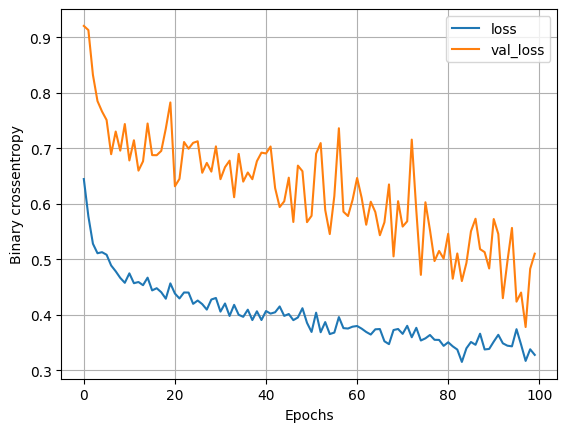

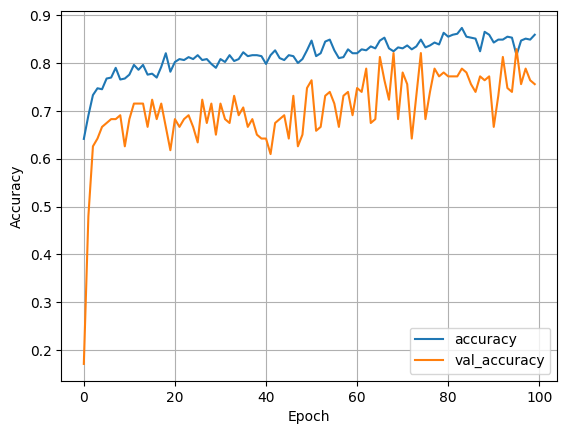

In [17]:
neural_network, history = build_and_train_nn(x_train, y_train, 0.01, 100, 64, 0.2)
plot_loss(history)
plot_accuracy(history)

#Make prediction

In [19]:
predict = neural_network.predict(x_test)
predict = (predict > 0.5).astype(int)
print(classification_report(y_test, predict))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
              precision    recall  f1-score   support

           0       0.78      0.92      0.85       104
           1       0.74      0.46      0.57        50

    accuracy                           0.77       154
   macro avg       0.76      0.69      0.71       154
weighted avg       0.77      0.77      0.76       154

